# Gillespie Parameter Grid Analysis

This notebook analyzes results from the Gillespie parameter grid simulations.

**Directory**: `/home/pol_schiessel/maya620d/pol/Projects/Codebase/Spermatogensis/cluster_output/gillespie_parameter_grid`

**Contents**:
- ~10,000 nucleosome trajectories per parameter set
- Both bound and unbound promoter regions
- Multiple parameter combinations (k_wrap, protamine concentration, cooperativity)

**Analysis includes**:
1. Index exploration and parameter ranges
2. Survival function computation and plotting
3. MFPT (Mean First Passage Time) analysis
4. Parameter comparison across conditions
5. Summary statistics visualization

**Tools used**:
- **Polars**: Efficient lazy loading and processing of large trajectory files
- **SimulationStorage**: Query and organize parameter sets
- **Matplotlib/Plotly**: Visualization

## Setup and Imports

In [5]:

%load_ext autoreload
%autoreload 2


In [6]:
import sys
from pathlib import Path

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Tuple
import json

# Import custom modules
from src.config.storage import SimulationStorage
# from src.config.path import RESULTS_DIR

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Configure display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

print("✓ Imports successful")
print(f"Project root: {project_root}")

✓ Imports successful
Project root: /home/pol_schiessel/maya620d/pol/Projects/Codebase/Spermatogensis


## 1. Load Simulation Index

In [7]:
# Initialize storage system
RESULTS_DIR = Path("/home/pol_schiessel/maya620d/pol/Projects/Codebase/Spermatogensis/cluster_output/gillespie_parameter_grid")

print(f"Results directory: {RESULTS_DIR}")
print(f"Exists: {RESULTS_DIR.exists()}")

# Initialize storage with index
storage = SimulationStorage(RESULTS_DIR, use_index=True)

# Check if index exists, rebuild if needed
index_file = RESULTS_DIR / "simulation_index.csv"
if not index_file.exists():
    print("\nIndex not found. Rebuilding...")
    index = storage.rebuild_index()
else:
    print("\n✓ Loading existing index...")
    index = storage.list_all_simulations()

print(f"\nTotal parameter sets: {len(index)}")
print(f"\nIndex columns: {list(index.columns)}")

Results directory: /home/pol_schiessel/maya620d/pol/Projects/Codebase/Spermatogensis/cluster_output/gillespie_parameter_grid
Exists: True

✓ Loading existing index...

Total parameter sets: 6

Index columns: ['directory', 'k_wrap', 'inf_protamine', 'tau_max', 'tau_steps', 'k_unbind', 'k_bind', 'p_conc', 'cooperativity', 'binding_sites', 'replicates']


## 2. Explore Parameter Space

In [8]:
# Display index summary
print("=" * 70)
print("PARAMETER SPACE SUMMARY")
print("=" * 70)

# Show unique parameter values
param_cols = ['k_wrap', 'k_unbind', 'k_bind', 'p_conc', 'cooperativity', 'inf_protamine']

for col in param_cols:
    if col in index.columns:
        unique_vals = sorted(index[col].dropna().unique())
        print(f"\n{col:20s}: {len(unique_vals)} unique values")
        print(f"  Values: {unique_vals}")

# Show first few entries
print("\n" + "=" * 70)
print("First 5 parameter sets:")
print("=" * 70)
display(index.head())

PARAMETER SPACE SUMMARY

k_wrap              : 1 unique values
  Values: [np.float64(1.0)]

k_unbind            : 1 unique values
  Values: [np.float64(89.7)]

k_bind              : 1 unique values
  Values: [np.float64(1.0)]

p_conc              : 5 unique values
  Values: [np.float64(0.0), np.float64(100.0), np.float64(500.0), np.float64(1000.0), np.float64(5000.0)]

cooperativity       : 2 unique values
  Values: [np.float64(0.0), np.float64(4.5)]

inf_protamine       : 1 unique values
  Values: [np.True_]

First 5 parameter sets:


,directory,k_wrap,inf_protamine,tau_max,tau_steps,k_unbind,k_bind,p_conc,cooperativity,binding_sites,replicates
0,k1.0_p100.0_c4.5_inf__7cddb7,1.0,True,10000.0,1000,89.7,1.0,100.0,4.5,14,12
1,k1.0_p1000.0_c4.5_inf__6a2ef1,1.0,True,10000.0,1000,89.7,1.0,1000.0,4.5,14,12
2,k1.0_p100.0_c0.0_inf__e8d348,1.0,True,10000.0,1000,89.7,1.0,100.0,0.0,14,12
3,k1.0_p0.0_c0.0_inf__e4cf32,1.0,True,10000.0,1000,89.7,1.0,0.0,0.0,14,12
4,k1.0_p5000.0_c4.5_inf__e4a783,1.0,True,10000.0,1000,89.7,1.0,5000.0,4.5,14,12


## 3. Load Trajectory Data with Polars

We'll use Polars lazy loading to efficiently process large trajectory files without loading everything into memory.

In [9]:
def load_trajectories_lazy(param_dir: Path, dataset_type: str = 'both', max_files: int = None) -> dict:
    """
    Load trajectory files using Polars lazy loading, separately for bound and unbound.
    
    Args:
        param_dir: Directory containing trajectories subdirectory
        dataset_type: 'bound', 'unbound', or 'both' (default: 'both')
        max_files: Maximum number of files to load per type (None = all)
    
    Returns:
        Dictionary with keys 'bound' and/or 'unbound' containing LazyFrames,
        or a single LazyFrame if only one type is requested
    """
    traj_dir = param_dir / "trajectories"
    
    if not traj_dir.exists():
        print(f"Warning: Trajectories directory not found: {traj_dir}")
        return None
    
    def load_type(file_pattern: str):
        """Helper to load files matching a pattern"""
        parquet_files = sorted(traj_dir.glob(file_pattern))
        
        if max_files:
            parquet_files = parquet_files[:max_files]
        
        if len(parquet_files) == 0:
            return None
        
        # Use Polars scan_parquet for lazy loading
        lf = pl.scan_parquet([str(f) for f in parquet_files])
        return lf
    
    results = {}
    
    if dataset_type in ['bound', 'both']:
        bound_lf = load_type("bound_*.parquet")
        if bound_lf is not None:
            results['bound'] = bound_lf
            print(f"  Loaded bound trajectory files (lazy)")
    
    if dataset_type in ['unbound', 'both']:
        unbound_lf = load_type("unbound_*.parquet")
        if unbound_lf is not None:
            results['unbound'] = unbound_lf
            print(f"  Loaded unbound trajectory files (lazy)")
    
    # If only one type requested, return LazyFrame directly
    if dataset_type != 'both' and len(results) == 1:
        return list(results.values())[0]
    
    return results if results else None


def load_summaries(param_dir: Path, dataset_type: str = 'both', max_files: int = None) -> dict:
    """
    Load summary TSV files separately for bound and unbound datasets.
    
    Args:
        param_dir: Directory containing summaries subdirectory
        dataset_type: 'bound', 'unbound', or 'both' (default: 'both')
        max_files: Maximum number of files to load per type (None = all)
    
    Returns:
        Dictionary with keys 'bound' and/or 'unbound' containing Polars DataFrames,
        or a single DataFrame if only one type is requested
    """
    summary_dir = param_dir / "summaries"
    
    if not summary_dir.exists():
        print(f"Warning: Summaries directory not found: {summary_dir}")
        return None
    
    def load_type(file_pattern: str):
        """Helper to load files matching a pattern"""
        tsv_files = sorted(summary_dir.glob(file_pattern))
        
        if max_files:
            tsv_files = tsv_files[:max_files]
        
        if len(tsv_files) == 0:
            return None
        
        # Read all files as strings first to avoid type conflicts
        dfs = []
        for tsv_file in tsv_files:
            try:
                # Read with strings for problematic columns, then cast
                df = pl.read_csv(
                    tsv_file, 
                    separator='\t',
                    infer_schema_length=10000
                )
                dfs.append(df)
            except Exception as e:
                print(f"Warning: Could not load {tsv_file.name}: {e}")
                continue
        
        if len(dfs) == 0:
            return None
        
        # Concatenate with diagonal to handle any schema differences
        try:
            summary_df = pl.concat(dfs, how="diagonal")
            return summary_df
        except Exception as e:
            print(f"Error concatenating files: {e}")
            return None
    
    results = {}
    
    if dataset_type in ['bound', 'both']:
        bound_df = load_type("bound_*.tsv")
        if bound_df is not None:
            results['bound'] = bound_df
            print(f"  Loaded {len(bound_df)} bound summaries")
    
    if dataset_type in ['unbound', 'both']:
        unbound_df = load_type("unbound_*.tsv")
        if unbound_df is not None:
            results['unbound'] = unbound_df
            print(f"  Loaded {len(unbound_df)} unbound summaries")
    
    # If only one type requested, return DataFrame directly
    if dataset_type != 'both' and len(results) == 1:
        return list(results.values())[0]
    
    return results if results else None


print("✓ Data loading functions defined")

✓ Data loading functions defined


## 4. Select Parameter Set for Analysis

Choose a specific parameter set to analyze in detail.

In [10]:
# Select a parameter set (modify these values as needed)
SELECTED_PARAMS = {
    'k_wrap': 1.0,
    'p_conc': 5000.0,
    'cooperativity': 4.5,
    'inf_protamine': True
}

print("Searching for parameter set:")
for key, val in SELECTED_PARAMS.items():
    print(f"  {key:20s}: {val}")

# Find matching simulations
matches = storage.find_simulations(**SELECTED_PARAMS)

print(f"\nFound {len(matches)} matching parameter set(s)")

if len(matches) > 0:
    print("\nMatching directories:")
    display(matches[['directory', 'k_wrap', 'p_conc', 'cooperativity', 'inf_protamine']])
    
    # Use the first match
    selected_dir = matches.iloc[0]['full_path']
    print(f"\n✓ Selected directory: {selected_dir}")
else:
    print("\n⚠ No matching parameter set found!")
    print("Available parameter combinations:")
    display(index[['k_wrap', 'p_conc', 'cooperativity', 'inf_protamine']].drop_duplicates())

Searching for parameter set:
  k_wrap              : 1.0
  p_conc              : 5000.0
  cooperativity       : 4.5
  inf_protamine       : True

Found 1 matching parameter set(s)

Matching directories:


,directory,k_wrap,p_conc,cooperativity,inf_protamine
4,k1.0_p5000.0_c4.5_inf__e4a783,1.0,5000.0,4.5,True



✓ Selected directory: /home/pol_schiessel/maya620d/pol/Projects/Codebase/Spermatogensis/cluster_output/gillespie_parameter_grid/k1.0_p5000.0_c4.5_inf__e4a783


## 5. Load and Inspect Data

In [11]:
# Load parameters from selected directory
params_file = selected_dir / "parameters.json"
with open(params_file, 'r') as f:
    params = json.load(f)

print("=" * 70)
print("LOADED PARAMETERS")
print("=" * 70)
print(json.dumps(params, indent=2))

# Load summaries (these are small, can load fully)
print("\n" + "=" * 70)
print("LOADING SUMMARY DATA")
print("=" * 70)
summaries_dict = load_summaries(selected_dir)

if summaries_dict is not None:
    print(f"\n✓ Loaded summary data")
    
    # Display bound summaries
    if 'bound' in summaries_dict:
        print(f"\n--- BOUND PROMOTER REGIONS ---")
        print(f"Rows: {len(summaries_dict['bound'])}")
        print(f"Columns: {summaries_dict['bound'].columns}")
        print(f"\nFirst few rows:")
        display(summaries_dict['bound'].head())
    
    # Display unbound summaries
    if 'unbound' in summaries_dict:
        print(f"\n--- UNBOUND PROMOTER REGIONS ---")
        print(f"Rows: {len(summaries_dict['unbound'])}")
        print(f"Columns: {summaries_dict['unbound'].columns}")
        print(f"\nFirst few rows:")
        display(summaries_dict['unbound'].head())
else:
    print("⚠ No summary data found")

LOADED PARAMETERS
{
  "k_wrap": 1.0,
  "prot_params": {
    "k_unbind": 89.7,
    "k_bind": 1.0,
    "p_conc": 5000.0,
    "cooperativity": 4.5
  },
  "binding_sites": 14,
  "tau_max": 10000.0,
  "tau_steps": 1000,
  "inf_protamine": true,
  "replicates": 12
}

LOADING SUMMARY DATA
  Loaded 16009 bound summaries
  Loaded 18154 unbound summaries

✓ Loaded summary data

--- BOUND PROMOTER REGIONS ---
Rows: 16009
Columns: ['id', 'subid', 'n_replicates', 'avg_cs_total', 'avg_bprot', 'avg_detach_time']

First few rows:


id,subid,n_replicates,avg_cs_total,avg_bprot,avg_detach_time
str,i64,i64,f64,f64,str
"""ENST00000330636.9""",1959,12,1.083333,12.083333,"""5998.998998998999"""
"""ENST00000330651.11""",525,12,0.0,13.0,"""3236.5699032365696"""
"""ENST00000330651.11""",2208,12,0.0,13.0,"""1780.9476142809478"""
"""ENST00000330651.11""",2458,12,0.0,13.0,"""2451.6182849516185"""
"""ENST00000330684.4""",1021,12,0.0,13.0,"""917.5842509175842"""



--- UNBOUND PROMOTER REGIONS ---
Rows: 18154
Columns: ['id', 'subid', 'n_replicates', 'avg_cs_total', 'avg_bprot', 'avg_detach_time']

First few rows:


id,subid,n_replicates,avg_cs_total,avg_bprot,avg_detach_time
str,i64,i64,f64,f64,str
"""ENST00000610445.2""",2015,12,0.0,13.0,"""455.4554554554555"""
"""ENST00000610445.2""",2025,12,0.0,13.0,"""1265.432098765432"""
"""ENST00000612278.4""",2019,12,0.0,13.0,"""47.547547547547545"""
"""ENST00000612278.4""",2029,12,0.0,13.0,"""283.6169502836169"""
"""ENST00000617704.1""",2013,12,0.0,12.916667,"""526.3596930263598"""


In [12]:
# Load trajectories (lazy - won't execute until we compute)
print("=" * 70)
print("LOADING TRAJECTORY DATA (LAZY)")
print("=" * 70)

trajectories_dict = load_trajectories_lazy(selected_dir, max_files=None)

if trajectories_dict is not None:
    print("\n✓ Lazy trajectory loader initialized")
    
    # Inspect bound trajectories
    if 'bound' in trajectories_dict:
        print(f"\n--- BOUND PROMOTER REGIONS ---")
        print(f"Schema: {trajectories_dict['bound'].schema}")
        n_rows = trajectories_dict['bound'].select(pl.count()).collect().item()
        print(f"Total trajectory rows: {n_rows:,}")
        print("\nSample rows:")
        display(trajectories_dict['bound'].head(5).collect())
    
    # Inspect unbound trajectories
    if 'unbound' in trajectories_dict:
        print(f"\n--- UNBOUND PROMOTER REGIONS ---")
        print(f"Schema: {trajectories_dict['unbound'].schema}")
        n_rows = trajectories_dict['unbound'].select(pl.count()).collect().item()
        print(f"Total trajectory rows: {n_rows:,}")
        print("\nSample rows:")
        display(trajectories_dict['unbound'].head(5).collect())
else:
    print("⚠ No trajectory data found")

LOADING TRAJECTORY DATA (LAZY)
  Loaded bound trajectory files (lazy)
  Loaded unbound trajectory files (lazy)

✓ Lazy trajectory loader initialized

--- BOUND PROMOTER REGIONS ---
Schema: Schema({'id': String, 'subid': Int64, 'replicate': Int64, 'tau_time': List(Float64), 'cs_total': List(Int64), 'bprot': List(Int64), 'detached_total': List(Int64)})
Total trajectory rows: 192,108

Sample rows:


/tmp/ipykernel_2570974/4153442386.py:14: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  print(f"Schema: {trajectories_dict['bound'].schema}")
/tmp/ipykernel_2570974/4153442386.py:15: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  n_rows = trajectories_dict['bound'].select(pl.count()).collect().item()


id,subid,replicate,tau_time,cs_total,bprot,detached_total
str,i64,i64,list[f64],list[i64],list[i64],list[i64]
"""ENST00000330636.9""",1959,0,"[0.0, 20.02002, … 10000.0]","[14, 14, … 0]","[0, 0, … 13]","[0, 0, … 1]"
"""ENST00000330636.9""",1959,1,"[0.0, 20.02002, … 10000.0]","[14, 13, … 0]","[0, 1, … 13]","[0, 0, … 1]"
"""ENST00000330636.9""",1959,2,"[0.0, 20.02002, … 10000.0]","[14, 14, … 12]","[0, 0, … 2]","[0, 0, … 0]"
"""ENST00000330636.9""",1959,3,"[0.0, 20.02002, … 10000.0]","[14, 13, … 0]","[0, 1, … 13]","[0, 0, … 1]"
"""ENST00000330636.9""",1959,4,"[0.0, 20.02002, … 10000.0]","[14, 13, … 0]","[0, 1, … 13]","[0, 0, … 1]"



--- UNBOUND PROMOTER REGIONS ---
Schema: Schema({'id': String, 'subid': Int64, 'replicate': Int64, 'tau_time': List(Float64), 'cs_total': List(Int64), 'bprot': List(Int64), 'detached_total': List(Int64)})
Total trajectory rows: 217,848

Sample rows:


/tmp/ipykernel_2570974/4153442386.py:23: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  print(f"Schema: {trajectories_dict['unbound'].schema}")
/tmp/ipykernel_2570974/4153442386.py:24: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  n_rows = trajectories_dict['unbound'].select(pl.count()).collect().item()


id,subid,replicate,tau_time,cs_total,bprot,detached_total
str,i64,i64,list[f64],list[i64],list[i64],list[i64]
"""ENST00000610445.2""",2015,0,"[0.0, 20.02002, … 10000.0]","[14, 13, … 0]","[0, 1, … 13]","[0, 0, … 1]"
"""ENST00000610445.2""",2015,1,"[0.0, 20.02002, … 10000.0]","[14, 14, … 0]","[0, 0, … 13]","[0, 0, … 1]"
"""ENST00000610445.2""",2015,2,"[0.0, 20.02002, … 10000.0]","[14, 14, … 0]","[0, 0, … 13]","[0, 0, … 1]"
"""ENST00000610445.2""",2015,3,"[0.0, 20.02002, … 10000.0]","[14, 14, … 0]","[0, 0, … 13]","[0, 0, … 1]"
"""ENST00000610445.2""",2015,4,"[0.0, 20.02002, … 10000.0]","[14, 13, … 0]","[0, 1, … 13]","[0, 0, … 1]"


## 6. Compute Survival Function

The survival function S(t) represents the probability that a nucleosome has not yet fully detached at time t.

In [13]:
def compute_survival_function(trajectories_lf: pl.LazyFrame, 
                             t_max: float = None,
                             n_bins: int = 500) -> Tuple[np.ndarray, np.ndarray]:
    """
    Compute survival function from trajectory data.
    
    S(t) = P(T_detach > t) = fraction of nucleosomes still attached at time t
    
    Args:
        trajectories_lf: Lazy trajectory data with columns:
                        - id, subid, replicate: identifiers
                        - tau_time: List[float] - time points
                        - detached_total: List[int] - detachment state (1=detached, 0=attached)
        t_max: Maximum time to consider (None = auto-detect)
        n_bins: Number of time bins
    
    Returns:
        t_grid: Time points
        survival: Survival probability at each time point
    """
    print("Computing survival function...")
    
    # Explode list columns to get time series data
    # Each row becomes multiple rows, one per time point
    exploded = (
        trajectories_lf
        .select([
            pl.col('id'),
            pl.col('subid'),
            pl.col('replicate'),
            pl.col('tau_time').alias('time'),
            pl.col('detached_total').alias('detached')
        ])
        .explode(['time', 'detached'])  # Explode lists in parallel
    )
    
    # Create unique nucleosome ID from id + subid + replicate
    exploded = exploded.with_columns(
        (pl.col('id').cast(str) + '_' + 
         pl.col('subid').cast(str) + '_' + 
         pl.col('replicate').cast(str)).alias('nuc_id')
    )
    
    # Get first detachment time for each nucleosome (when detached==1)
    detachment_data = (
        exploded
        .filter(pl.col('detached') == 1)  # Filter to detached state
        .group_by('nuc_id')  # Group by nucleosome
        .agg(pl.col('time').min().alias('t_detach'))  # First detachment time
        .collect()
    )
    
    detachment_times = detachment_data['t_detach'].to_numpy()
    n_total = len(detachment_times)
    
    print(f"  Total nucleosomes with detachment: {n_total}")
    if n_total > 0:
        print(f"  Detachment time range: [{detachment_times.min():.2f}, {detachment_times.max():.2f}]")
    else:
        print("  WARNING: No detachment events found!")
        return np.array([0.0]), np.array([1.0])
    
    # Create time grid
    if t_max is None:
        t_max = detachment_times.max() * 1.1
    
    t_grid = np.linspace(0, t_max, n_bins)
    
    # Compute survival: S(t) = fraction with t_detach > t
    survival = np.array([np.sum(detachment_times > t) / n_total for t in t_grid])
    
    return t_grid, survival


# Compute survival functions for both bound and unbound
survival_results = {}

if trajectories_dict is not None:
    for dataset_type in ['bound', 'unbound']:
        if dataset_type in trajectories_dict:
            print(f"\n{'='*70}")
            print(f"Computing survival function for {dataset_type.upper()} regions...")
            print(f"{'='*70}")
            
            t_grid, survival = compute_survival_function(trajectories_dict[dataset_type], n_bins=500)
            survival_results[dataset_type] = {'t_grid': t_grid, 'survival': survival}
            
            print(f"\n✓ {dataset_type.capitalize()} survival function computed")
            print(f"  S(0) = {survival[0]:.4f} (should be ~1.0)")
            print(f"  S(t_max) = {survival[-1]:.6f}")
            print(f"  S(t_max/2) = {survival[len(survival)//2]:.4f}")
else:
    print("⚠ Cannot compute survival function without trajectory data")


Computing survival function for BOUND regions...
Computing survival function...
  Total nucleosomes with detachment: 172444
  Detachment time range: [20.02, 10000.00]

✓ Bound survival function computed
  S(0) = 1.0000 (should be ~1.0)
  S(t_max) = 0.000000
  S(t_max/2) = 0.1081

Computing survival function for UNBOUND regions...
Computing survival function...
  Total nucleosomes with detachment: 210889
  Detachment time range: [20.02, 10000.00]

✓ Unbound survival function computed
  S(0) = 1.0000 (should be ~1.0)
  S(t_max) = 0.000000
  S(t_max/2) = 0.0371


## 7. Plot Survival Function

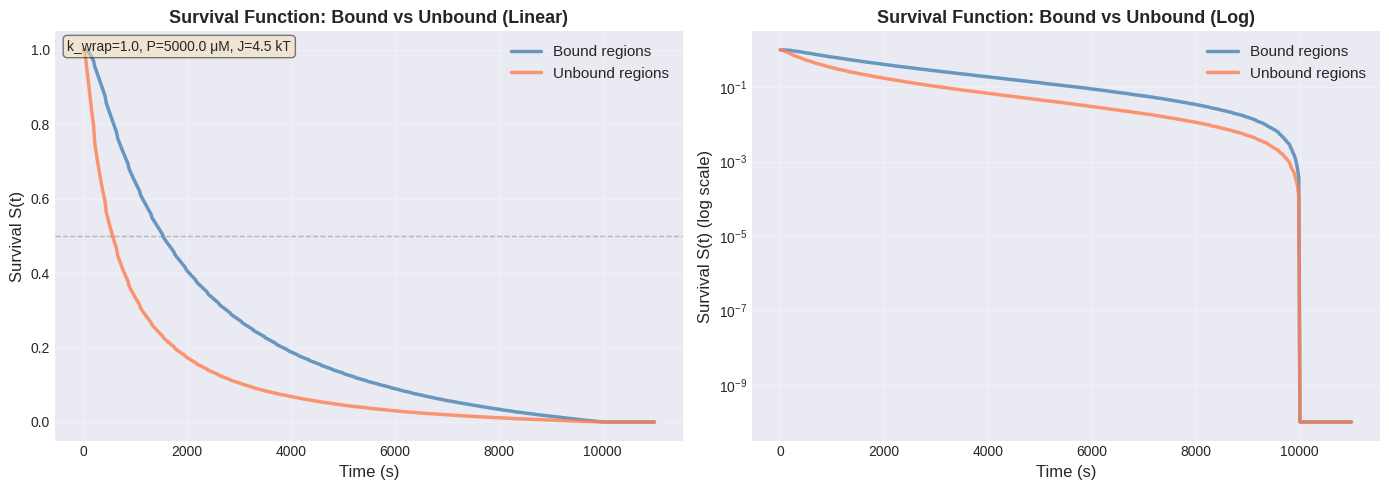

✓ Survival function plot saved to output/survival_function.png


In [14]:
if len(survival_results) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    colors = {'bound': 'steelblue', 'unbound': 'coral'}
    
    # Plot both datasets if available
    for dataset_type, data in survival_results.items():
        t_grid = data['t_grid']
        survival = data['survival']
        color = colors[dataset_type]
        label = f"{dataset_type.capitalize()} regions"
        
        # Linear scale
        axes[0].plot(t_grid, survival, lw=2.5, alpha=0.8, color=color, label=label)
        
        # Log scale
        axes[1].semilogy(t_grid, survival + 1e-10, lw=2.5, alpha=0.8, color=color, label=label)
    
    # Format linear scale plot
    axes[0].set_xlabel('Time (s)', fontsize=12)
    axes[0].set_ylabel('Survival S(t)', fontsize=12)
    axes[0].set_title('Survival Function: Bound vs Unbound (Linear)', fontsize=13, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.5, lw=1)
    axes[0].legend(fontsize=11)
    
    # Add parameter info
    param_text = f"k_wrap={SELECTED_PARAMS['k_wrap']:.1f}, "
    param_text += f"P={SELECTED_PARAMS['p_conc']:.1f} μM, "
    param_text += f"J={SELECTED_PARAMS['cooperativity']:.1f} kT"
    axes[0].text(0.02, 0.98, param_text, transform=axes[0].transAxes,
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Format log scale plot
    axes[1].set_xlabel('Time (s)', fontsize=12)
    axes[1].set_ylabel('Survival S(t) (log scale)', fontsize=12)
    axes[1].set_title('Survival Function: Bound vs Unbound (Log)', fontsize=13, fontweight='bold')
    axes[1].grid(True, alpha=0.3, which='both')
    axes[1].legend(fontsize=11)
    
    plt.tight_layout()
    plt.savefig('output/survival_function.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("✓ Survival function plot saved to output/survival_function.png")

## 7b. Plot Survival Function for Specific Nucleosome

Analyze and plot the survival function for a specific nucleosome identified by its ID and subid.

SINGLE NUCLEOSOME SURVIVAL ANALYSIS

Available nucleosomes (first 20 from each dataset):

BOUND regions:


id,subid
str,i64
"""ENST00000330636.9""",1959
"""ENST00000330651.11""",525
"""ENST00000330651.11""",2208
"""ENST00000330651.11""",2458
"""ENST00000330684.4""",1021
…,…
"""ENST00000330817.11""",2365
"""ENST00000330828.3""",1437
"""ENST00000330843.9""",2226



UNBOUND regions:


id,subid
str,i64
"""ENST00000610445.2""",2015
"""ENST00000610445.2""",2025
"""ENST00000612278.4""",2019
"""ENST00000612278.4""",2029
"""ENST00000617704.1""",2013
…,…
"""ENST00000624187.1""",2029
"""ENST00000624596.2""",2013
"""ENST00000624596.2""",2024



Analyzing nucleosome: ENST00000016171.6, subid=2025
Dataset: unbound
Computing survival function for nucleosome ENST00000016171.6, subid=2025...
  Found 12 replicates
  Detachment time range: [320.32, 4024.02]


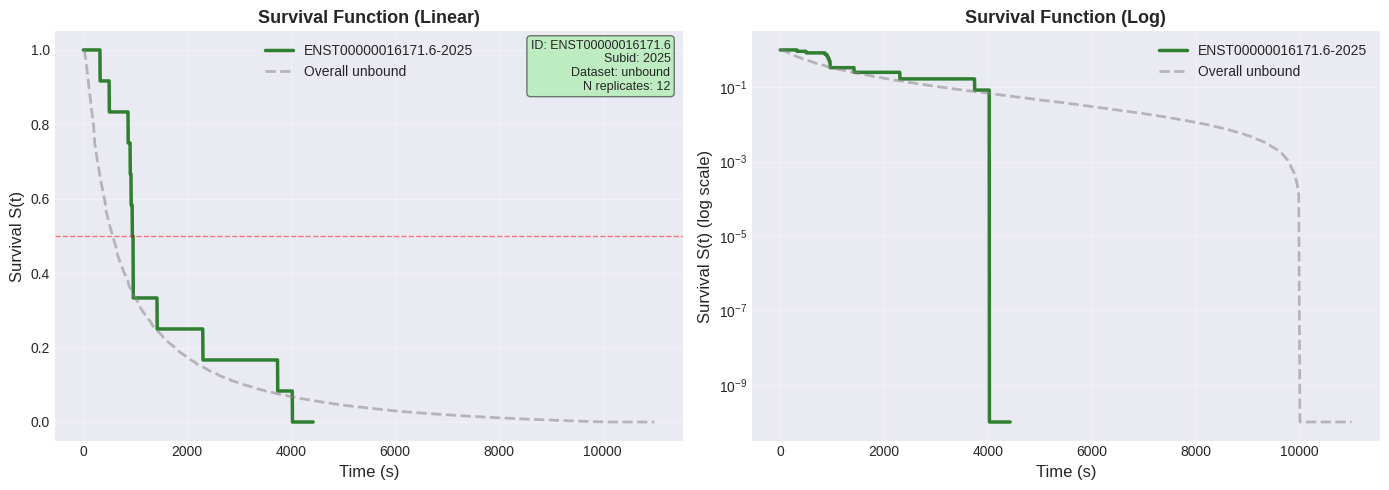


✓ Nucleosome survival plot saved to output/survival_nucleosome_ENST00000016171.6_2025.png

Statistics for ENST00000016171.6, subid=2025:
  Half-life (t₁/₂): 943.77 seconds
  Final survival S(t_max): 0.000000

Plotting mean trajectory (averaged across all replicates)...
Computing mean trajectory for ENST00000016171.6, subid=2025...
  Found 12 replicates
  Time range: [0.00, 10000.00]
  Mean trajectory computed from 12 replicates


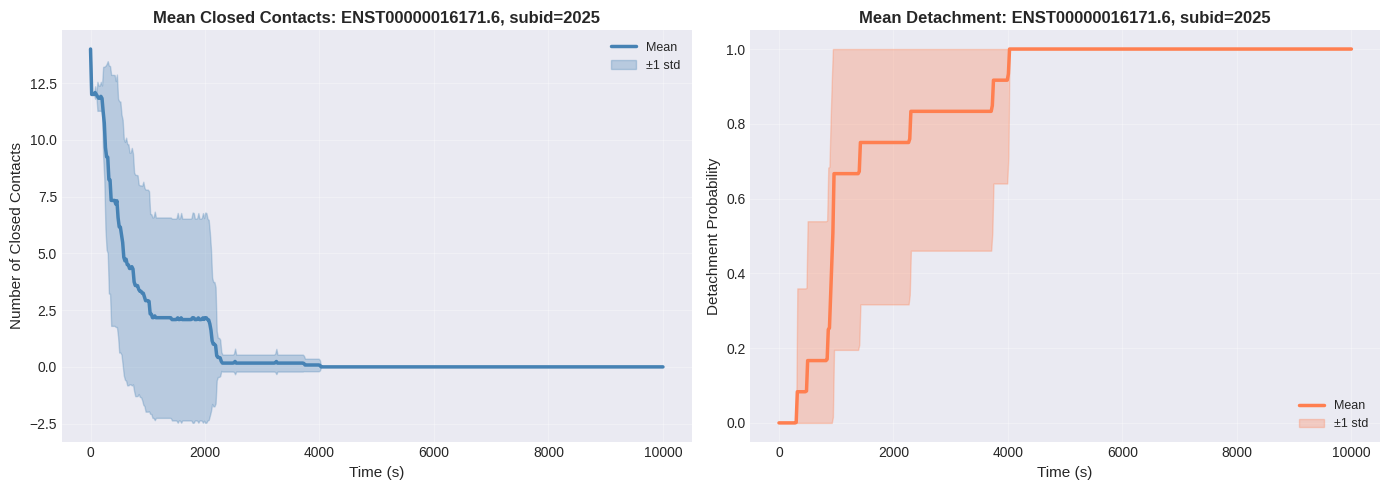

✓ Mean trajectory plot saved to output/mean_trajectory_nucleosome_ENST00000016171.6_2025.png


In [16]:
def compute_single_nucleosome_survival(trajectories_lf: pl.LazyFrame, 
                                       target_id: str,
                                       target_subid: int,
                                       t_max: float = None,
                                       n_bins: int = 500) -> Tuple[np.ndarray, np.ndarray, int]:
    """
    Compute survival function for a specific nucleosome across all replicates.
    
    Args:
        trajectories_lf: Lazy trajectory data
        target_id: Target nucleosome ID (e.g., 'ENST00000330636.9')
        target_subid: Target subid
        t_max: Maximum time to consider (None = auto-detect)
        n_bins: Number of time bins
    
    Returns:
        t_grid: Time points
        survival: Survival probability at each time point
        n_replicates: Number of replicates found
    """
    print(f"Computing survival function for nucleosome {target_id}, subid={target_subid}...")
    
    # Filter for specific nucleosome and explode
    exploded = (
        trajectories_lf
        .filter(
            (pl.col('id') == target_id) & 
            (pl.col('subid') == target_subid)
        )
        .select([
            pl.col('id'),
            pl.col('subid'),
            pl.col('replicate'),
            pl.col('tau_time').alias('time'),
            pl.col('detached_total').alias('detached')
        ])
        .explode(['time', 'detached'])
    )
    
    # Create unique replicate ID
    exploded = exploded.with_columns(
        pl.col('replicate').cast(str).alias('replicate_id')
    )
    
    # Get first detachment time for each replicate
    detachment_data = (
        exploded
        .filter(pl.col('detached') == 1)
        .group_by('replicate_id')
        .agg(pl.col('time').min().alias('t_detach'))
        .collect()
    )
    
    if len(detachment_data) == 0:
        print("  WARNING: No detachment events found for this nucleosome!")
        return np.array([0.0]), np.array([1.0]), 0
    
    detachment_times = detachment_data['t_detach'].to_numpy()
    n_replicates = len(detachment_times)
    
    print(f"  Found {n_replicates} replicates")
    print(f"  Detachment time range: [{detachment_times.min():.2f}, {detachment_times.max():.2f}]")
    
    # Create time grid
    if t_max is None:
        t_max = detachment_times.max() * 1.1
    
    t_grid = np.linspace(0, t_max, n_bins)
    
    # Compute survival: S(t) = fraction with t_detach > t
    survival = np.array([np.sum(detachment_times > t) / n_replicates for t in t_grid])
    
    return t_grid, survival, n_replicates


def compute_mean_trajectory(trajectories_lf: pl.LazyFrame,
                            target_id: str,
                            target_subid: int,
                            n_bins: int = 500) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Compute mean trajectory (averaged across replicates) for a specific nucleosome.
    
    Args:
        trajectories_lf: Lazy trajectory data
        target_id: Target nucleosome ID
        target_subid: Target subid
        n_bins: Number of time bins for interpolation
    
    Returns:
        t_grid: Common time grid
        mean_closed: Mean number of closed contacts over time
        std_closed: Standard deviation of closed contacts
        mean_detached: Mean detachment status (fraction detached at each time)
        std_detached: Standard deviation of detachment status
    """
    print(f"Computing mean trajectory for {target_id}, subid={target_subid}...")
    
    # Load all replicates for this nucleosome
    nuc_data = (
        trajectories_lf
        .filter(
            (pl.col('id') == target_id) & 
            (pl.col('subid') == target_subid)
        )
        .select([
            pl.col('replicate'),
            pl.col('tau_time').alias('time'),
            pl.col('cs_total').alias('n_closed'),
            pl.col('detached_total').alias('detached')
        ])
        .collect()
    )
    
    if len(nuc_data) == 0:
        print("  No data found!")
        return None, None, None, None, None
    
    print(f"  Found {len(nuc_data)} replicates")
    
    # Find global time range across all replicates
    all_times = []
    for row in nuc_data.iter_rows(named=True):
        if row['time']:
            all_times.extend(row['time'])
    
    if len(all_times) == 0:
        print("  No time data found!")
        return None, None, None, None, None
    
    t_min, t_max = min(all_times), max(all_times)
    t_grid = np.linspace(t_min, t_max, n_bins)
    
    print(f"  Time range: [{t_min:.2f}, {t_max:.2f}]")
    
    # Interpolate each replicate onto common time grid
    closed_interpolated = []
    detached_interpolated = []
    
    for row in nuc_data.iter_rows(named=True):
        time_list = row['time']
        closed_list = row['n_closed']
        detached_list = row['detached']
        
        if time_list and closed_list and len(time_list) == len(closed_list):
            # Interpolate closed contacts
            closed_interp = np.interp(t_grid, time_list, closed_list)
            closed_interpolated.append(closed_interp)
            
            # Interpolate detachment status
            detached_interp = np.interp(t_grid, time_list, detached_list)
            detached_interpolated.append(detached_interp)
    
    if len(closed_interpolated) == 0:
        print("  No valid trajectories to interpolate!")
        return None, None, None, None, None
    
    # Convert to arrays and compute statistics
    closed_array = np.array(closed_interpolated)
    detached_array = np.array(detached_interpolated)
    
    mean_closed = np.mean(closed_array, axis=0)
    std_closed = np.std(closed_array, axis=0)
    
    mean_detached = np.mean(detached_array, axis=0)
    std_detached = np.std(detached_array, axis=0)
    
    print(f"  Mean trajectory computed from {len(closed_interpolated)} replicates")
    
    return t_grid, mean_closed, std_closed, mean_detached, std_detached


def plot_mean_trajectory(trajectories_lf: pl.LazyFrame,
                        target_id: str,
                        target_subid: int,
                        n_bins: int = 500):
    """
    Plot mean trajectory (averaged across replicates) for a specific nucleosome.
    
    Args:
        trajectories_lf: Lazy trajectory data
        target_id: Target nucleosome ID
        target_subid: Target subid
        n_bins: Number of time bins for interpolation
    """
    # Compute mean trajectory
    result = compute_mean_trajectory(trajectories_lf, target_id, target_subid, n_bins)
    
    if result[0] is None:
        print(f"  Cannot plot mean trajectory for {target_id}, subid={target_subid}")
        return None
    
    t_grid, mean_closed, std_closed, mean_detached, std_detached = result
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Mean closed contacts with uncertainty band
    axes[0].plot(t_grid, mean_closed, lw=2.5, color='steelblue', label='Mean')
    axes[0].fill_between(t_grid, 
                         mean_closed - std_closed, 
                         mean_closed + std_closed,
                         alpha=0.3, color='steelblue', label='±1 std')
    
    axes[0].set_xlabel('Time (s)', fontsize=11)
    axes[0].set_ylabel('Number of Closed Contacts', fontsize=11)
    axes[0].set_title(f'Mean Closed Contacts: {target_id}, subid={target_subid}', 
                     fontsize=12, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(fontsize=9)
    
    # Plot 2: Mean detachment status (fraction detached)
    axes[1].plot(t_grid, mean_detached, lw=2.5, color='coral', label='Mean')
    axes[1].fill_between(t_grid,
                         np.maximum(0, mean_detached - std_detached),
                         np.minimum(1, mean_detached + std_detached),
                         alpha=0.3, color='coral', label='±1 std')
    
    axes[1].set_xlabel('Time (s)', fontsize=11)
    axes[1].set_ylabel('Detachment Probability', fontsize=11)
    axes[1].set_title(f'Mean Detachment: {target_id}, subid={target_subid}', 
                     fontsize=12, fontweight='bold')
    axes[1].set_ylim([-0.05, 1.05])
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(fontsize=9)
    
    plt.tight_layout()
    
    return fig


# Interactive selection and plotting
print("=" * 70)
print("SINGLE NUCLEOSOME SURVIVAL ANALYSIS")
print("=" * 70)

# Show available nucleosomes from summaries
if summaries_dict is not None and len(summaries_dict) > 0:
    print("\nAvailable nucleosomes (first 20 from each dataset):")
    
    for dataset_type in ['bound', 'unbound']:
        if dataset_type in summaries_dict:
            summaries = summaries_dict[dataset_type]
            sample = summaries.select(['id', 'subid']).head(20)
            print(f"\n{dataset_type.upper()} regions:")
            display(sample)

# Example: Plot survival for a specific nucleosome
# Modify these values to analyze different nucleosomes
ANALYZE_NUCLEOSOME = {
    'id': 'ENST00000016171.6',  # Replace with desired nucleosome ID
    'subid': 2025,               # Replace with desired subid
    'dataset': 'unbound'           # 'bound' or 'unbound'
}

print(f"\n{'='*70}")
print(f"Analyzing nucleosome: {ANALYZE_NUCLEOSOME['id']}, subid={ANALYZE_NUCLEOSOME['subid']}")
print(f"Dataset: {ANALYZE_NUCLEOSOME['dataset']}")
print(f"{'='*70}")

if trajectories_dict is not None and ANALYZE_NUCLEOSOME['dataset'] in trajectories_dict:
    # Compute survival function for this specific nucleosome
    t_grid_nuc, survival_nuc, n_reps = compute_single_nucleosome_survival(
        trajectories_dict[ANALYZE_NUCLEOSOME['dataset']],
        ANALYZE_NUCLEOSOME['id'],
        ANALYZE_NUCLEOSOME['subid'],
        n_bins=1000
    )

    if n_reps > 0:
        # Plot survival function
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Linear scale
        axes[0].plot(t_grid_nuc, survival_nuc, lw=2.5, alpha=0.8, 
                    color='darkgreen', label=f'{ANALYZE_NUCLEOSOME["id"]}-{ANALYZE_NUCLEOSOME["subid"]}')
        
        # Compare with overall dataset if available
        if ANALYZE_NUCLEOSOME['dataset'] in survival_results:
            overall_data = survival_results[ANALYZE_NUCLEOSOME['dataset']]
            axes[0].plot(overall_data['t_grid'], overall_data['survival'], 
                        lw=2, alpha=0.5, color='gray', linestyle='--',
                        label=f'Overall {ANALYZE_NUCLEOSOME["dataset"]}')
        
        axes[0].set_xlabel('Time (s)', fontsize=12)
        axes[0].set_ylabel('Survival S(t)', fontsize=12)
        axes[0].set_title(f'Survival Function (Linear)', fontsize=13, fontweight='bold')
        axes[0].axhline(0.5, color='red', linestyle='--', alpha=0.5, lw=1)
        axes[0].grid(True, alpha=0.3)
        axes[0].legend(fontsize=10)
        
        # Add info text
        info_text = f"ID: {ANALYZE_NUCLEOSOME['id']}\n"
        info_text += f"Subid: {ANALYZE_NUCLEOSOME['subid']}\n"
        info_text += f"Dataset: {ANALYZE_NUCLEOSOME['dataset']}\n"
        info_text += f"N replicates: {n_reps}"
        axes[0].text(0.98, 0.98, info_text, transform=axes[0].transAxes,
                    fontsize=9, verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
        
        # Log scale
        axes[1].semilogy(t_grid_nuc, survival_nuc + 1e-10, lw=2.5, alpha=0.8, 
                        color='darkgreen', label=f'{ANALYZE_NUCLEOSOME["id"]}-{ANALYZE_NUCLEOSOME["subid"]}')
        
        if ANALYZE_NUCLEOSOME['dataset'] in survival_results:
            overall_data = survival_results[ANALYZE_NUCLEOSOME['dataset']]
            axes[1].semilogy(overall_data['t_grid'], overall_data['survival'] + 1e-10, 
                            lw=2, alpha=0.5, color='gray', linestyle='--',
                            label=f'Overall {ANALYZE_NUCLEOSOME["dataset"]}')
        
        axes[1].set_xlabel('Time (s)', fontsize=12)
        axes[1].set_ylabel('Survival S(t) (log scale)', fontsize=12)
        axes[1].set_title(f'Survival Function (Log)', fontsize=13, fontweight='bold')
        axes[1].grid(True, alpha=0.3, which='both')
        axes[1].legend(fontsize=10)
        
        plt.tight_layout()
        plt.savefig(f'output/survival_nucleosome_{ANALYZE_NUCLEOSOME["id"]}_{ANALYZE_NUCLEOSOME["subid"]}.png', 
                   dpi=150, bbox_inches='tight')
        plt.show()
        
        print(f"\n✓ Nucleosome survival plot saved to output/survival_nucleosome_{ANALYZE_NUCLEOSOME['id']}_{ANALYZE_NUCLEOSOME['subid']}.png")
        
        # Calculate statistics
        median_idx = np.argmin(np.abs(survival_nuc - 0.5))
        t_half = t_grid_nuc[median_idx]
        
        print(f"\nStatistics for {ANALYZE_NUCLEOSOME['id']}, subid={ANALYZE_NUCLEOSOME['subid']}:")
        print(f"  Half-life (t₁/₂): {t_half:.2f} seconds")
        print(f"  Final survival S(t_max): {survival_nuc[-1]:.6f}")
        
        # Plot MEAN trajectory (NEW!)
        print(f"\nPlotting mean trajectory (averaged across all replicates)...")
        fig_mean = plot_mean_trajectory(
            trajectories_dict[ANALYZE_NUCLEOSOME['dataset']],
            ANALYZE_NUCLEOSOME['id'],
            ANALYZE_NUCLEOSOME['subid'],
            n_bins=500
        )
        
        if fig_mean is not None:
            fig_mean.savefig(f'output/mean_trajectory_nucleosome_{ANALYZE_NUCLEOSOME["id"]}_{ANALYZE_NUCLEOSOME["subid"]}.png',
                            dpi=150, bbox_inches='tight')
            plt.show()
            print(f"✓ Mean trajectory plot saved to output/mean_trajectory_nucleosome_{ANALYZE_NUCLEOSOME['id']}_{ANALYZE_NUCLEOSOME['subid']}.png")
    else:
        print("\n⚠ No replicates found for this nucleosome")
else:
    print("\n⚠ Cannot analyze specific nucleosome without trajectory data")

## 8. Compute MFPT from Summaries

In [ ]:
if summaries_dict is not None:
    print("=" * 70)
    print("MEAN FIRST PASSAGE TIME (MFPT) ANALYSIS")
    print("=" * 70)
    
    mfpt_results = {}
    
    for dataset_type in ['bound', 'unbound']:
        if dataset_type not in summaries_dict:
            continue
            
        summaries = summaries_dict[dataset_type]
        print(f"\n--- {dataset_type.UPPER()} REGIONS ---")
        print(f"Available columns: {summaries.columns}")
        
        # Column should be 'avg_detach_time' based on the schema
        if 'avg_detach_time' in summaries.columns:
            # Filter out non-finite values
            valid_times = summaries.filter(pl.col('avg_detach_time').is_finite())['avg_detach_time']
            
            if len(valid_times) > 0:
                mfpt = valid_times.mean()
                mfpt_std = valid_times.std()
                mfpt_median = valid_times.median()
                
                mfpt_results[dataset_type] = {
                    'mean': mfpt,
                    'std': mfpt_std,
                    'median': mfpt_median,
                    'times': valid_times.to_numpy()
                }
                
                print(f"\nMFPT Statistics:")
                print(f"  Mean:   {mfpt:.4f} ± {mfpt_std:.4f} seconds")
                print(f"  Median: {mfpt_median:.4f} seconds")
                print(f"  Min:    {valid_times.min():.4f} seconds")
                print(f"  Max:    {valid_times.max():.4f} seconds")
                print(f"  N:      {len(valid_times)} nucleosomes")
            else:
                print("  ⚠ No valid detachment times found")
        else:
            print(f"  ⚠ Column 'avg_detach_time' not found")
    
    # Plot MFPT comparison
    if len(mfpt_results) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        colors = {'bound': 'steelblue', 'unbound': 'coral'}
        
        for dataset_type, data in mfpt_results.items():
            color = colors[dataset_type]
            label = f"{dataset_type.capitalize()}"
            times = data['times']
            
            # Histogram
            axes[0].hist(times, bins=50, edgecolor='black', 
                        alpha=0.6, color=color, label=label)
            axes[0].axvline(data['mean'], color=color, linestyle='--', lw=2, alpha=0.8)
        
        axes[0].set_xlabel('Detachment Time (s)', fontsize=12)
        axes[0].set_ylabel('Count', fontsize=12)
        axes[0].set_title('MFPT Distribution: Bound vs Unbound', fontsize=13, fontweight='bold')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # CDF comparison
        for dataset_type, data in mfpt_results.items():
            color = colors[dataset_type]
            label = f"{dataset_type.capitalize()} (median={data['median']:.1f}s)"
            times = data['times']
            sorted_times = np.sort(times)
            cdf = np.arange(1, len(sorted_times) + 1) / len(sorted_times)
            axes[1].plot(sorted_times, cdf, lw=2.5, color=color, label=label)
        
        axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
        axes[1].set_xlabel('Detachment Time (s)', fontsize=12)
        axes[1].set_ylabel('Cumulative Probability', fontsize=12)
        axes[1].set_title('Cumulative Distribution: Bound vs Unbound', fontsize=13, fontweight='bold')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('output/mfpt_distribution.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        print("\n✓ MFPT distribution plot saved to output/mfpt_distribution.png")

MEAN FIRST PASSAGE TIME (MFPT) ANALYSIS

Available columns: ['id', 'subid', 'n_replicates', 'avg_cs_total', 'avg_bprot', 'avg_detach_time']

Time-related columns: ['avg_detach_time']

⚠ No detachment time column found in summaries
Available columns: ['id', 'subid', 'n_replicates', 'avg_cs_total', 'avg_bprot', 'avg_detach_time']


## 9. Compare Multiple Parameter Sets

Load and compare results across different parameter combinations.

In [35]:
# Define parameter sets to compare
COMPARE_PARAMS = [
    {'p_conc': 100.0, 'cooperativity': 0.0, 'label': 'No protamine'},
    {'p_conc': 100.0, 'cooperativity': 4.5, 'label': 'Low P, no coop'},
    {'p_conc': 1000.0, 'cooperativity': 4.5, 'label': 'High P, no coop'},
    {'p_conc': 5000.0, 'cooperativity': 4.5, 'label': 'High P + coop'},
]

print("Comparing parameter sets:")
for params in COMPARE_PARAMS:
    print(f"  - {params['label']}")

# Find all matching parameter sets
comparison_data = []

for param_set in COMPARE_PARAMS:
    # Search for this parameter combination
    search_params = {k: v for k, v in param_set.items() if k != 'label'}
    search_params['k_wrap'] = SELECTED_PARAMS['k_wrap']  # Keep k_wrap constant
    search_params['inf_protamine'] = SELECTED_PARAMS['inf_protamine']
    print(f"\nSearching for: {param_set['label']} with params {search_params}")
    
    matches = storage.find_simulations(**search_params)
    
    if len(matches) > 0:
        param_dir = matches.iloc[0]['full_path']
        print(f"✓ Found directory: {param_dir}")
        summaries_i = load_summaries(param_dir)
        
        if summaries_i is not None:
            # Process both bound and unbound data
            for dataset_type in ['bound', 'unbound']:
                if dataset_type not in summaries_i:
                    continue
                    
                summaries_df = summaries_i[dataset_type]
                
                if 'avg_detach_time' in summaries_df.columns:
                    valid_times = summaries_df.filter(pl.col('avg_detach_time').is_finite())['avg_detach_time']
                    
                    comparison_data.append({
                        'label': param_set['label'],
                        'dataset': dataset_type,
                        'p_conc': param_set['p_conc'],
                        'cooperativity': param_set['cooperativity'],
                        'mfpt_mean': valid_times.mean(),
                        'mfpt_std': valid_times.std(),
                        'mfpt_median': valid_times.median(),
                        'n_samples': len(valid_times),
                        'param_dir': param_dir
                    })
                    print(f"✓ Loaded {dataset_type} data for: {param_set['label']}")
                else:
                    print(f"⚠ No avg_detach_time column in {dataset_type} data for: {param_set['label']}")
        else:
            print(f"⚠ No summary data for: {param_set['label']}")
    else:
        print(f"⚠ No matching directory for: {param_set['label']}")

# Convert to DataFrame for easy plotting
if len(comparison_data) > 0:
    comparison_df = pd.DataFrame(comparison_data)
    print(f"\n✓ Loaded {len(comparison_df)} parameter sets for comparison")
    display(comparison_df[['label', 'mfpt_mean', 'mfpt_std', 'n_samples']])
else:
    print("\n⚠ No parameter sets loaded for comparison")

Comparing parameter sets:
  - No protamine
  - Low P, no coop
  - High P, no coop
  - High P + coop

Searching for: No protamine with params {'p_conc': 100.0, 'cooperativity': 0.0, 'k_wrap': 1.0, 'inf_protamine': True}
✓ Found directory: /home/pol_schiessel/maya620d/pol/Projects/Codebase/Spermatogensis/cluster_output/gillespie_parameter_grid/k1.0_p100.0_c0.0_inf__e8d348
Found 2 summary files
Loaded summaries with shape: (34163, 6)
⚠ No summary data for: No protamine

Searching for: Low P, no coop with params {'p_conc': 100.0, 'cooperativity': 4.5, 'k_wrap': 1.0, 'inf_protamine': True}
✓ Found directory: /home/pol_schiessel/maya620d/pol/Projects/Codebase/Spermatogensis/cluster_output/gillespie_parameter_grid/k1.0_p100.0_c4.5_inf__7cddb7
Found 2 summary files
Loaded summaries with shape: (34163, 6)
⚠ No summary data for: Low P, no coop

Searching for: High P, no coop with params {'p_conc': 1000.0, 'cooperativity': 4.5, 'k_wrap': 1.0, 'inf_protamine': True}
✓ Found directory: /home/pol_sc

In [36]:
# Plot comparison
if len(comparison_data) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Separate bound and unbound data
    bound_df = comparison_df[comparison_df['dataset'] == 'bound']
    unbound_df = comparison_df[comparison_df['dataset'] == 'unbound']
    
    # MFPT bar chart - Grouped by label, showing bound vs unbound
    labels = comparison_df['label'].unique()
    x = np.arange(len(labels))
    width = 0.35
    
    bound_means = [bound_df[bound_df['label'] == l]['mfpt_mean'].values[0] if l in bound_df['label'].values else 0 for l in labels]
    bound_stds = [bound_df[bound_df['label'] == l]['mfpt_std'].values[0] if l in bound_df['label'].values else 0 for l in labels]
    unbound_means = [unbound_df[unbound_df['label'] == l]['mfpt_mean'].values[0] if l in unbound_df['label'].values else 0 for l in labels]
    unbound_stds = [unbound_df[unbound_df['label'] == l]['mfpt_std'].values[0] if l in unbound_df['label'].values else 0 for l in labels]
    
    axes[0].bar(x - width/2, bound_means, width, yerr=bound_stds,
               label='Bound', alpha=0.7, capsize=5, edgecolor='black', color='steelblue')
    axes[0].bar(x + width/2, unbound_means, width, yerr=unbound_stds,
               label='Unbound', alpha=0.7, capsize=5, edgecolor='black', color='coral')
    
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels, rotation=45, ha='right')
    axes[0].set_ylabel('MFPT (seconds)', fontsize=12)
    axes[0].set_title('MFPT: Bound vs Unbound Promoters', fontsize=13, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # Effect of protamine concentration - separate lines for bound/unbound
    if 'p_conc' in comparison_df.columns:
        for dataset_type in ['bound', 'unbound']:
            subset = comparison_df[comparison_df['dataset'] == dataset_type]
            color = 'steelblue' if dataset_type == 'bound' else 'coral'
            marker = 'o' if dataset_type == 'bound' else 's'
            
            # Group by cooperativity
            for coop in subset['cooperativity'].unique():
                coop_subset = subset[subset['cooperativity'] == coop]
                label = f"{dataset_type.capitalize()}, J={coop:.1f} kT" if coop > 0 else f"{dataset_type.capitalize()}, no coop"
                axes[1].errorbar(coop_subset['p_conc'], coop_subset['mfpt_mean'],
                               yerr=coop_subset['mfpt_std'],
                               marker=marker, markersize=10, lw=2, capsize=5,
                               label=label, alpha=0.8, color=color)
        
        axes[1].set_xlabel('Protamine Concentration (μM)', fontsize=12)
        axes[1].set_ylabel('MFPT (seconds)', fontsize=12)
        axes[1].set_title('Effect of Protamine Concentration', fontsize=13, fontweight='bold')
        axes[1].legend(fontsize=9)
        axes[1].grid(True, alpha=0.3)
        axes[1].set_xscale('log')
    
    plt.tight_layout()
    plt.savefig('output/parameter_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("✓ Parameter comparison plot saved to output/parameter_comparison.png")

## 10. Survival Function Comparison

In [37]:
# Compare survival functions across parameter sets
if len(comparison_data) > 0:
    print("Computing survival functions for all parameter sets...")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Get unique parameter directories to avoid reloading
    param_dirs = comparison_df['param_dir'].unique()
    
    for param_dir in param_dirs:
        # Get label for this parameter set
        label = comparison_df[comparison_df['param_dir'] == param_dir]['label'].iloc[0]
        
        # Load trajectories for both bound and unbound
        traj_dict = load_trajectories_lazy(param_dir, max_files=50)  # Limit for speed
        
        if traj_dict is not None:
            for dataset_type in ['bound', 'unbound']:
                if dataset_type not in traj_dict:
                    continue
                    
                t_grid, survival = compute_survival_function(traj_dict[dataset_type], n_bins=300)
                
                # Choose line style based on dataset type
                linestyle = '-' if dataset_type == 'bound' else '--'
                alpha = 0.8 if dataset_type == 'bound' else 0.6
                plot_label = f"{label} ({dataset_type})"
                
                # Linear scale
                axes[0].plot(t_grid, survival, lw=2.5, alpha=alpha,
                            linestyle=linestyle, label=plot_label)
                
                # Log scale
                axes[1].semilogy(t_grid, survival + 1e-10, lw=2.5, alpha=alpha,
                               linestyle=linestyle, label=plot_label)
    
    # Format linear scale plot
    axes[0].set_xlabel('Time (s)', fontsize=12)
    axes[0].set_ylabel('Survival S(t)', fontsize=12)
    axes[0].set_title('Survival Functions: Bound vs Unbound (Linear)', fontsize=13, fontweight='bold')
    axes[0].legend(fontsize=9, loc='best')
    axes[0].grid(True, alpha=0.3)
    axes[0].axhline(0.5, color='k', linestyle='--', alpha=0.3)
    
    # Format log scale plot
    axes[1].set_xlabel('Time (s)', fontsize=12)
    axes[1].set_ylabel('Survival S(t) (log scale)', fontsize=12)
    axes[1].set_title('Survival Functions: Bound vs Unbound (Log)', fontsize=13, fontweight='bold')
    axes[1].legend(fontsize=9, loc='best')
    axes[1].grid(True, alpha=0.3, which='both')
    
    plt.tight_layout()
    plt.savefig('output/survival_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Survival comparison plot saved to output/survival_comparison.png")

## 11. Additional Analysis: Trajectory Features

Analyzing trajectory features...
Sampling 5 random nucleosome trajectories...
✓ Loaded 5 trajectories (in list format)
  Exploded to 2505 time points
✓ Loaded 5 trajectories (in list format)
  Exploded to 2505 time points


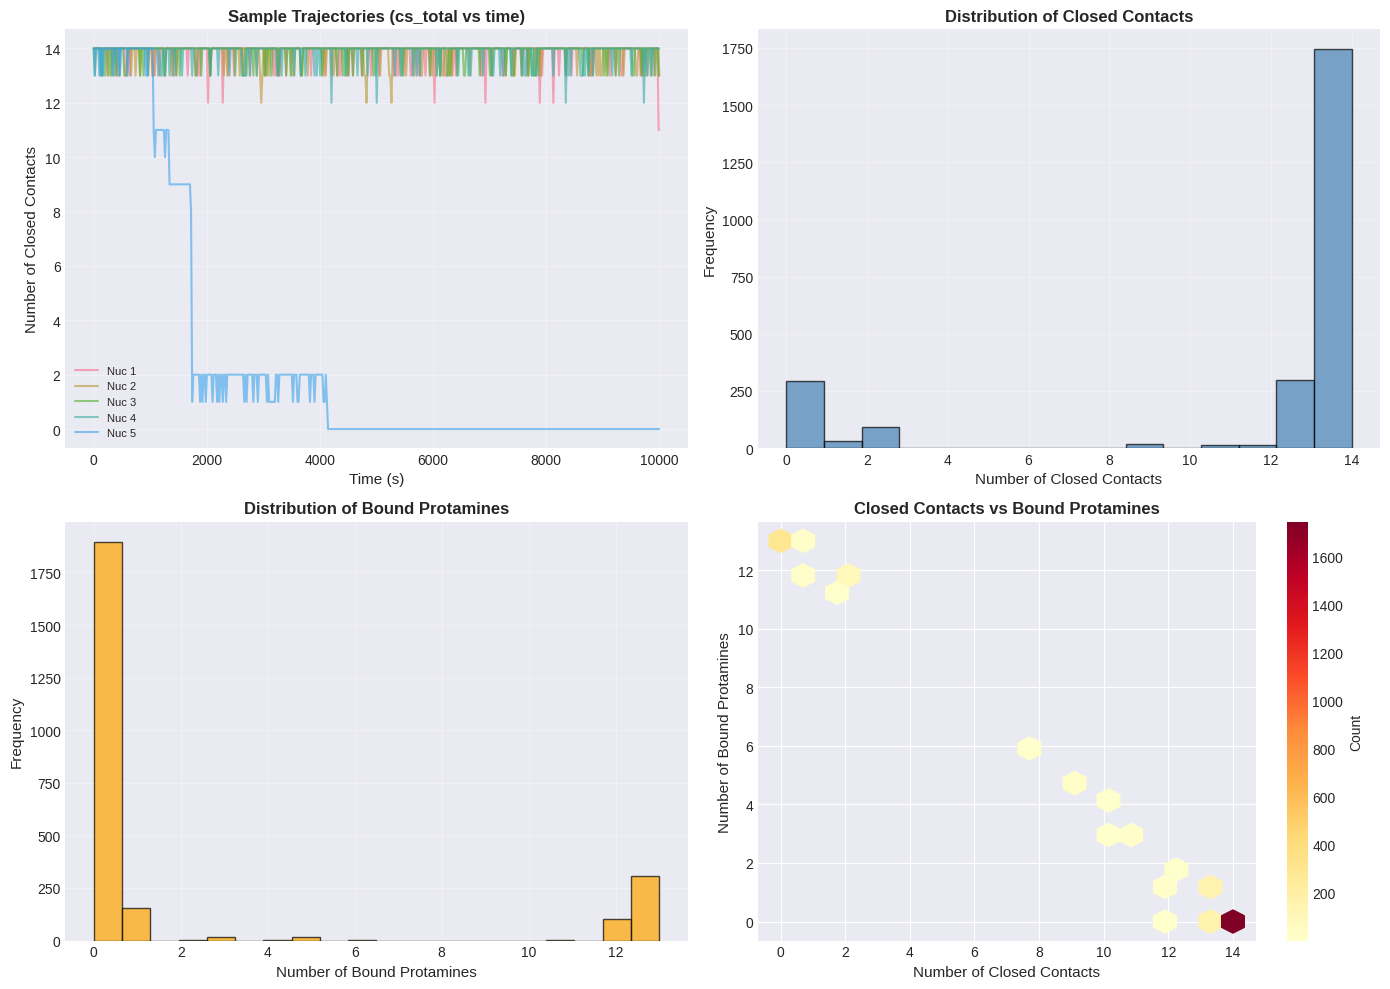

✓ Trajectory features plot saved to output/trajectory_features.png


In [31]:
# Analyze specific trajectory features if available
if trajectories_dict is not None and 'bound' in trajectories_dict:
    trajectories_lazy = trajectories_dict['bound']  # Use bound data for feature analysis
    print("Analyzing trajectory features...")
    
    # Sample a subset of trajectories for detailed analysis
    sample_size = 5  # Use fewer samples since we need to explode lists
    print(f"Sampling {sample_size} random nucleosome trajectories...")
    
    # Load a small sample and explode the lists
    sample_df = (
        trajectories_lazy
        .limit(sample_size)
        .select([
            pl.col('id'),
            pl.col('subid'),
            pl.col('replicate'),
            pl.col('tau_time').alias('time'),
            pl.col('cs_total').alias('n_closed'),
            pl.col('bprot').alias('n_bound_protamines'),
            pl.col('detached_total').alias('detached')
        ])
        .collect()
    )
    
    # Create unique nucleosome ID
    sample_df = sample_df.with_columns(
        (pl.col('id').cast(str) + '_' + 
         pl.col('subid').cast(str) + '_' + 
         pl.col('replicate').cast(str)).alias('nuc_id')
    )
    
    print(f"✓ Loaded {len(sample_df)} trajectories (in list format)")
    
    # Plot sample trajectories
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot first few trajectories (without exploding for now)
    for i, row in enumerate(sample_df.head(5).iter_rows(named=True)):
        time_list = row['time']
        n_closed_list = row['n_closed']
        
        if time_list and n_closed_list and len(time_list) == len(n_closed_list):
            axes[0, 0].plot(time_list, n_closed_list, alpha=0.6, lw=1.5, 
                          label=f"Nuc {i+1}")
    
    axes[0, 0].set_xlabel('Time (s)', fontsize=11)
    axes[0, 0].set_ylabel('Number of Closed Contacts', fontsize=11)
    axes[0, 0].set_title('Sample Trajectories (cs_total vs time)', fontsize=12, fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend(fontsize=8)
    
    # For distributions, we need to explode the lists
    sample_exploded = (
        sample_df
        .select(['nuc_id', 'time', 'n_closed', 'n_bound_protamines'])
        .explode(['time', 'n_closed', 'n_bound_protamines'])
    )
    
    print(f"  Exploded to {len(sample_exploded)} time points")
    
    # Distribution of number of closed contacts at different times
    axes[0, 1].hist(sample_exploded['n_closed'].to_numpy(), bins=15, 
                   edgecolor='black', alpha=0.7, color='steelblue')
    axes[0, 1].set_xlabel('Number of Closed Contacts', fontsize=11)
    axes[0, 1].set_ylabel('Frequency', fontsize=11)
    axes[0, 1].set_title('Distribution of Closed Contacts', fontsize=12, fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Bound protamines distribution
    axes[1, 0].hist(sample_exploded['n_bound_protamines'].to_numpy(), bins=20,
                   edgecolor='black', alpha=0.7, color='orange')
    axes[1, 0].set_xlabel('Number of Bound Protamines', fontsize=11)
    axes[1, 0].set_ylabel('Frequency', fontsize=11)
    axes[1, 0].set_title('Distribution of Bound Protamines', fontsize=12, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Correlation between closed contacts and bound protamines
    axes[1, 1].hexbin(sample_exploded['n_closed'].to_numpy(),
                    sample_exploded['n_bound_protamines'].to_numpy(),
                    gridsize=20, cmap='YlOrRd', mincnt=1)
    axes[1, 1].set_xlabel('Number of Closed Contacts', fontsize=11)
    axes[1, 1].set_ylabel('Number of Bound Protamines', fontsize=11)
    axes[1, 1].set_title('Closed Contacts vs Bound Protamines', fontsize=12, fontweight='bold')
    cb = plt.colorbar(axes[1, 1].collections[0], ax=axes[1, 1], label='Count')
    cb.set_label('Count', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('output/trajectory_features.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("✓ Trajectory features plot saved to output/trajectory_features.png")

## 12. Summary Report

Generate a comprehensive summary of the analysis.

In [ ]:
print("=" * 70)
print("ANALYSIS SUMMARY")
print("=" * 70)

print(f"\nData Directory: {RESULTS_DIR}")
print(f"Total Parameter Sets: {len(index)}")

if len(comparison_data) > 0:
    print("\n" + "=" * 70)
    print("MFPT SUMMARY ACROSS PARAMETERS")
    print("=" * 70)
    
    for data in comparison_data:
        print(f"\n{data['label']}:")
        print(f"  Protamine conc: {data['p_conc']:.1f} μM")
        print(f"  Cooperativity:  {data['cooperativity']:.1f} kT")
        print(f"  MFPT:          {data['mfpt_mean']:.4f} ± {data['mfpt_std']:.4f} s")
        print(f"  Median MFPT:   {data['mfpt_median']:.4f} s")
        print(f"  N nucleosomes: {data['n_samples']}")
    
    # Calculate effect sizes
    if len(comparison_data) > 1:
        baseline = comparison_data[0]
        print("\n" + "=" * 70)
        print("RELATIVE EFFECTS (compared to baseline)")
        print("=" * 70)
        print(f"\nBaseline: {baseline['label']}")
        print(f"Baseline MFPT: {baseline['mfpt_mean']:.4f} s")
        
        for data in comparison_data[1:]:
            ratio = data['mfpt_mean'] / baseline['mfpt_mean']
            print(f"\n{data['label']}:")
            print(f"  MFPT ratio: {ratio:.3f}x")
            print(f"  Effect: {'Stabilizing' if ratio > 1 else 'Destabilizing'}")

print("\n" + "=" * 70)
print("GENERATED PLOTS")
print("=" * 70)
print("\n  1. output/gillespie_parameter_space.png")
print("  2. output/survival_function.png")
print("  3. output/mfpt_distribution.png")
print("  4. output/parameter_comparison.png")
print("  5. output/survival_comparison.png")
print("  6. output/trajectory_features.png")

print("\n" + "=" * 70)
print("✓ ANALYSIS COMPLETE")
print("=" * 70)

## 13. Export Results

Save analysis results to files for later use.

In [ ]:
# Create output directory if it doesn't exist
output_dir = Path('output')
output_dir.mkdir(exist_ok=True)

# Save comparison results
if len(comparison_data) > 0:
    comparison_df.to_csv('output/parameter_comparison_results.csv', index=False)
    print("✓ Saved parameter comparison results to output/parameter_comparison_results.csv")

# Save survival function data
if len(survival_results) > 0:
    for dataset_type, data in survival_results.items():
        survival_df = pd.DataFrame({
            'time': data['t_grid'],
            'survival': data['survival']
        })
        survival_df.to_csv(f'output/survival_function_{dataset_type}.csv', index=False)
        print(f"✓ Saved {dataset_type} survival function data to output/survival_function_{dataset_type}.csv")

# Save summary statistics
if summaries_dict is not None:
    for dataset_type, summaries in summaries_dict.items():
        summaries.write_csv(f'output/nucleosome_summaries_{dataset_type}.csv')
        print(f"✓ Saved {dataset_type} nucleosome summaries to output/nucleosome_summaries_{dataset_type}.csv")

print("\n✓ All results exported successfully")